In [ ]:
import json
import os

def clean_and_save_stead(input_path, output_path):
    print(f"📂 Membaca file: {input_path}")
    with open(input_path, 'r') as f:
        data = json.load(f)
        
    cleaned_data = {}
    removed_count = 0
    
    # Kita tambahkan validasi panjang array minimal
    MIN_LEN = 10 
    
    for key, rec in data.items():
        z_noise = rec.get('Z_noise', [])
        
        # Validasi: Pastikan list tidak kosong dan memiliki panjang cukup sebelum slicing
        if len(z_noise) >= MIN_LEN:
            # Cek 10 titik terakhir: apakah semuanya hampir nol?
            is_padded = all(abs(v) < 1e-7 for v in z_noise[-10:])
        else:
            # Jika sinyal terlalu pendek, anggap cacat/padding juga
            is_padded = True
        
        if not is_padded:
            cleaned_data[key] = rec
        else:
            removed_count += 1
            
    # Simpan hasil
    with open(output_path, 'w') as f:
        json.dump(cleaned_data, f, indent=2) # Indentasi 2 agar mudah dibaca jika perlu audit
        
    print(f"✅ Pembersihan Selesai.")
    print(f"Record Awal     : {len(data)}")
    print(f"Record Bersih   : {len(cleaned_data)}")
    print(f"Record Dihapus  : {removed_count}")
    print(f"Save Path       : {output_path}")

# Jalankan
clean_and_save_stead(
    '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_final.json',
    '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_final_clean.json'
)

📂 Membaca file: /Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_final.json
✅ Pembersihan Selesai.
Record Awal     : 5601
Record Bersih   : 5596
Record Dihapus  : 5
Save Path       : /Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_final_clean.json


📂 Membaca file: /Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_final.json
🔍 Menghitung SNR untuk 5601 record...


100%|██████████| 5601/5601 [00:00<00:00, 26030.82it/s]



✅ Pemfilteran Selesai.
Ambang Batas SNR: 3.0
Record Awal     : 5601
Record Lolos    : 3322
Record Dihapus  : 2279
Save Path       : /Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_SNR_HIGH.json


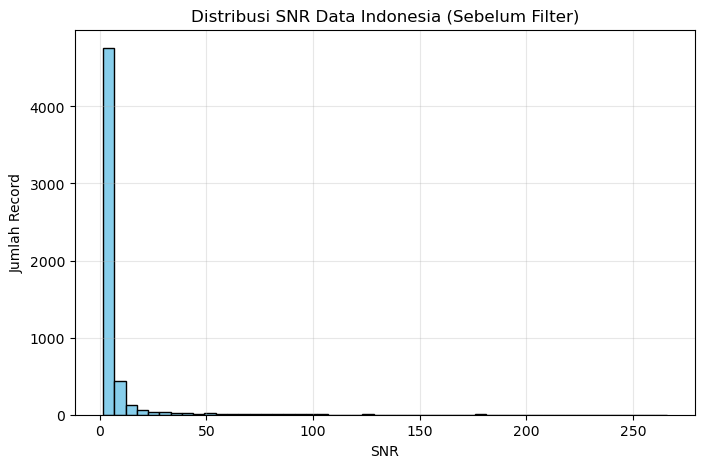

In [4]:
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

def calculate_snr(signal, noise):
    """Menghitung SNR: Max Sinyal / Std Dev Noise"""
    noise_std = np.std(noise)
    if noise_std < 1e-9: return 0
    return np.max(np.abs(signal)) / noise_std

def filter_dataset_by_snr(input_path, output_path, snr_threshold=3.0):
    print(f"📂 Membaca file: {input_path}")
    with open(input_path, 'r') as f:
        data = json.load(f)
        
    filtered_data = {}
    snr_values = []
    removed_count = 0
    
    print(f"🔍 Menghitung SNR untuk {len(data)} record...")
    
    for key, rec in tqdm(data.items()):
        # Pastikan data tersedia
        z_noise = np.array(rec.get('Z_noise', []))
        z_sig = np.array(rec.get('Z', []))
        
        if len(z_noise) > 0 and len(z_sig) > 0:
            snr = calculate_snr(z_sig, z_noise)
            snr_values.append(snr)
            
            # Hanya simpan jika SNR memenuhi ambang batas
            if snr >= snr_threshold:
                filtered_data[key] = rec
            else:
                removed_count += 1
        else:
            removed_count += 1
            
    # Simpan hasil
    with open(output_path, 'w') as f:
        json.dump(filtered_data, f, indent=2)
        
    print(f"\n✅ Pemfilteran Selesai.")
    print(f"Ambang Batas SNR: {snr_threshold}")
    print(f"Record Awal     : {len(data)}")
    print(f"Record Lolos    : {len(filtered_data)}")
    print(f"Record Dihapus  : {removed_count}")
    print(f"Save Path       : {output_path}")
    
    return snr_values

if __name__ == "__main__":
    # Menggunakan path yang Bapak berikan
    snr_list = filter_dataset_by_snr(
        '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_final.json',
        '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4_SNR_HIGH.json',
        snr_threshold=3.0
    )
    
    # Optional: Plot Histogram SNR untuk melihat distribusi kualitas data
    plt.figure(figsize=(8, 5))
    plt.hist(snr_list, bins=50, color='skyblue', edgecolor='black')
    plt.title("Distribusi SNR Data Indonesia (Sebelum Filter)")
    plt.xlabel("SNR")
    plt.ylabel("Jumlah Record")
    plt.grid(alpha=0.3)
    plt.show()